# Titanic Survival Analysis — Exploratory Data Analysis 

## Objective

The objective of this notebook is to investigate the characteristics associated with passenger survival aboard the Titanic.

The analysis aims to:

- Understand the distributions of individual variables.
- Examine relationships between predictors and the target variable.
- Explore interactions among features.
- Identify patterns and potential predictive signals.
- Generate hypotheses for feature engineering.
- Produce insights that will guide subsequent model development.


## Import Required Libraries

In [19]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## Dataset Overview

The cleaned dataset produced during the data wrangling stage is used for exploratory analysis.

Objectives:

- Load the processed dataset.
- Examine its structure.
- Verify dimensions and datatypes.
- Establish the analytical foundation for subsequent sections.

In [20]:
df = pd.read_csv('../data/processed/titanic_cleaned.csv')

df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [21]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (891, 9)


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 62.8 KB


### Observations

- The dataset contains cleaned observations from the Titanic passenger manifest.
- Missing values have been addressed during preprocessing.
- Features such as `Cabin`, `Ticket`, and `PassengerId` were removed.
- The dataset is ready for exploratory analysis.

## Target Variable Analysis

Understanding the target variable is essential before analyzing predictor relationships.

Questions:

- How many passengers survived?
- Is the target variable balanced?
- What baseline class distribution exists?

These insights influence model evaluation and metric selection.

In [23]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [24]:
survival_rate = df['Survived'].value_counts(normalize = True) * 100
survival_rate

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

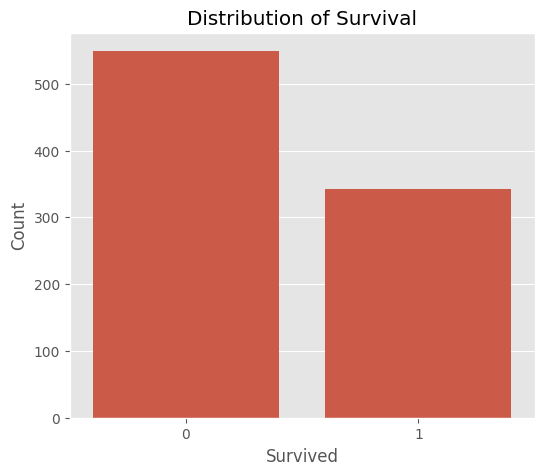

In [25]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Survived"
)

plt.title("Distribution of Survival")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

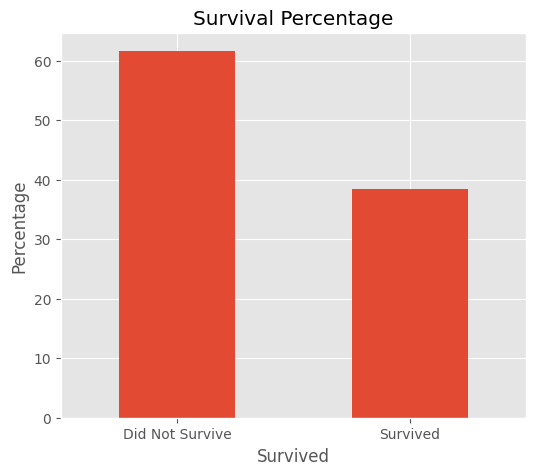

In [26]:
survival_percentage = (
    df["Survived"]
    .value_counts(normalize=True)
    .sort_index()*100
)

plt.figure(figsize=(6,5))

survival_percentage.plot(
    kind="bar"
)

plt.xticks(
    [0,1],
    ["Did Not Survive","Survived"],
    rotation=0
)

plt.ylabel("Percentage")
plt.title("Survival Percentage")

plt.show()

### Interpretation

The target variable is moderately imbalanced, with fatalities exceeding survivals. However, the imbalance is not severe enough to require special treatment at this stage.

### Key Insight

A larger proportion of passengers did not survive.

### Modeling Implication

Model evaluation should consider metrics beyond accuracy, such as precision, recall, and F1-score.

## Univariate Analysis

Univariate analysis focuses on understanding individual variables independently.

Objectives:

- Study distributions.
- Detect skewness.
- Understand spread and concentration.
- Identify dominant categories.
- Reveal potential feature engineering opportunities.

## Numerical Features

The numerical variables considered are:

- Age
- Fare
- SibSp
- Parch

For each variable, we investigate:

- Distribution
- Spread
- Skewness
- Potential outliers

In [27]:
numerical_columns = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

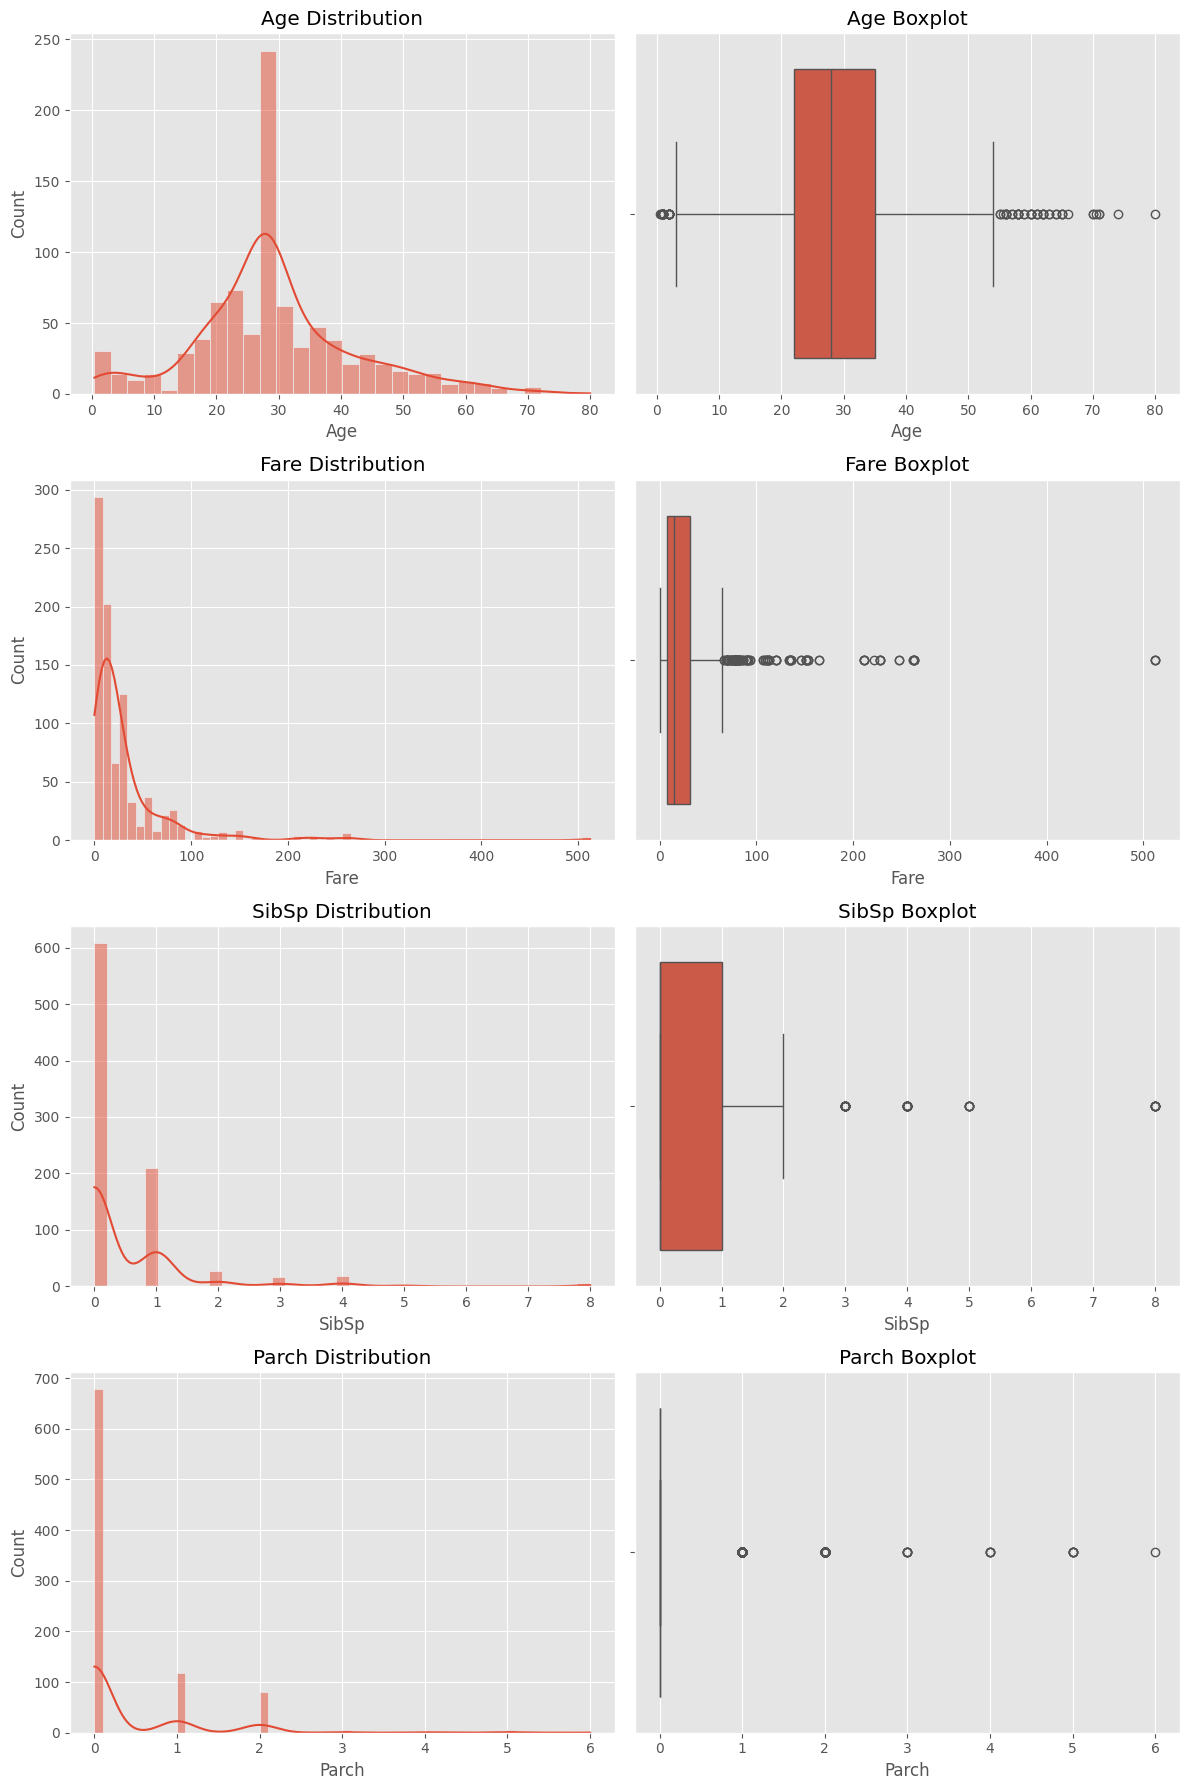

In [28]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(12,18)
)

for i, column in enumerate(numerical_columns):

    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=axes[i,0]
    )

    axes[i,0].set_title(f"{column} Distribution")

    sns.boxplot(
        data=df,
        x=column,
        ax=axes[i,1]
    )

    axes[i,1].set_title(f"{column} Boxplot")

plt.tight_layout()

plt.show()

### Interpretation

- Age exhibits a roughly bell-shaped distribution with slight skewness.
- Fare displays strong positive skewness and contains extreme values.
- Most passengers travelled with few relatives aboard.
- Large family sizes are relatively uncommon.

### Key Insight

The Fare variable contains substantial variability and may capture socioeconomic information.

### Modeling Implication

Transformations or engineered features derived from family structure and fare may improve predictive performance.

## Categorical Features

The categorical variables examined are:

- Sex
- Pclass
- Embarked

The objective is to understand category frequencies and class distributions.

In [29]:
categorical_columns = [
    "Sex",
    "Pclass",
    "Embarked"
]

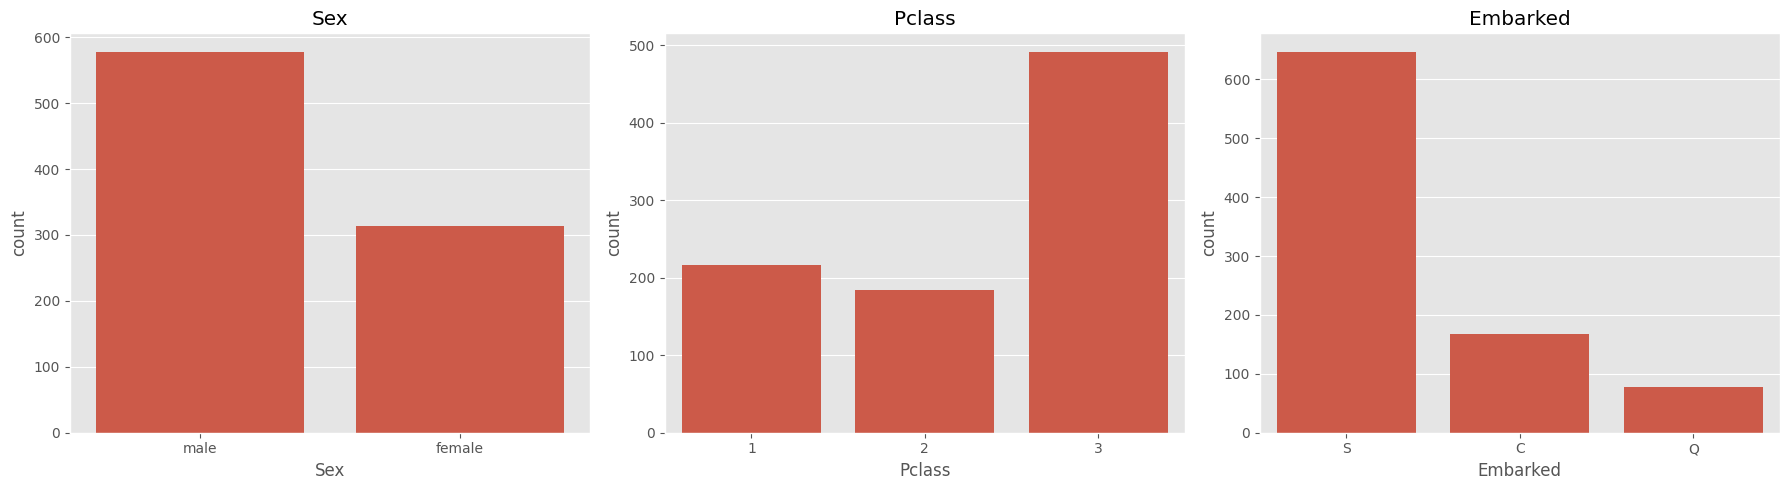

In [30]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18,5)
)

for i, column in enumerate(categorical_columns):

    sns.countplot(
        data=df,
        x=column,
        ax=axes[i]
    )

    axes[i].set_title(column)

plt.tight_layout()

plt.show()

### Interpretation

- Male passengers outnumber female passengers.
- Third-class passengers constitute the largest group.
- Southampton ('S') is the most common embarkation port.

### Key Insight

The dataset contains noticeable category imbalance, particularly within passenger class and embarkation location.

### Modeling Implication

These categorical variables may contain valuable predictive information and should be retained during feature engineering.